In [1]:
!pip install -q librosa scipy pandas openpyxl gdown matplotlib
!pip install -q transformers
!pip install -q torch torchaudio --index-url https://download.pytorch.org/whl/cu121

In [2]:
!pip install pytorch-tcn

In [3]:
!git clone https://github.com/MarijaGijic/AI-SPEAK_catB.git

Cloning into 'AI-SPEAK_catB'...
remote: Enumerating objects: 217, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (11/11), done.
Receiving objects: 100% (217/217), 81.79 KiB | 697.00 KiB/s, done.
remote: Total 217 (delta 55), reused 54 (delta 51), pack-reused 155 (from 1)
Resolving deltas: 100% (120/120), done.


In [4]:
%cd AI-SPEAK_catB

/content/AI-SPEAK_catB


In [5]:
!python download_data.py

Downloading...
From (original): https://drive.google.com/uc?id=1AqENkQjMEC4BLUVaaXIueK4q-KwQyD7S
From (redirected): https://drive.google.com/uc?id=1AqENkQjMEC4BLUVaaXIueK4q-KwQyD7S&confirm=t&uuid=6c800b9d-eb9b-4df8-b18f-558fa1750be5
To: /content/AI-SPEAK_catB/data/spk14_blendshapes.zip
100% 59.4M/59.4M [00:00<00:00, 126MB/s]
Unzipping spk14_blendshapes.zip
Downloading...
From (original): https://drive.google.com/uc?id=1onjc_aw990qQAsvszLSI9rpXS2SkJFVd
From (redirected): https://drive.google.com/uc?id=1onjc_aw990qQAsvszLSI9rpXS2SkJFVd&confirm=t&uuid=239d32d8-3513-4fd7-b0be-5d49da54f8e9
To: /content/AI-SPEAK_catB/data/spk08_blendshapes.zip
100% 67.9M/67.9M [00:00<00:00, 114MB/s]
Unzipping spk08_blendshapes.zip
Downloading...
From: https://drive.google.com/uc?id=1KduEMO5DqqdQLXPd45W6knSFIuODxMqR
To: /content/AI-SPEAK_catB/data/labels_aligned.zip
100% 278k/278k [00:00<00:00, 5.00MB/s]
Unzipping labels_aligned.zip
Downloading...
From (original): https://drive.google.com/uc?id=16e8VnAhH2L-sm

In [6]:
import os
result_dict = "/content/results" # folder za cuvanje najboljih modela
SUBMIT_DIR = "submission" # folder za cuvanje rezultata inference
os.makedirs(SUBMIT_DIR, exist_ok=True)
print("Folder napravljen:", os.path.abspath(SUBMIT_DIR))

Folder napravljen: /content/AI-SPEAK_catB/submission


## Ekstrakcija HuBert feature-a

In [ ]:
# ekstrakcija HuBert feature-a
from scripts.precompute_hubert import precompute_hubert

precompute_hubert()

[HuBERT] Ucitavam facebook/hubert-base-ls960 na cpu ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

[HuBERT] Model spreman. HUBERT_DIM=768
Predracunavam HuBERT features...


spk08:   0%|          | 0/178 [00:00<?, ?it/s]

spk14:   0%|          | 0/180 [00:00<?, ?it/s]

Gotovo -- 358 fajlova u /content/hubert_features


## Ucitavanje fajlova i sanity check

In [7]:
from src.utils.dataset import BlendshapeDataset, collate_fn_mfcc, collate_fn_hubert
from src.config import BLENDSHAPE_NAMES
from torch.utils.data import DataLoader

DATA_ROOT = 'data'
HUBERT_DIR = '/content/hubert_features'
ds = BlendshapeDataset(DATA_ROOT, speakers=['spk08', 'spk14'], load_synth=False, use_preprocessing=True, hubert_dir=HUBERT_DIR)


if len(ds) == 0:
    print('\n[!] 0 samples — checking structure:')
    import os
    for root, dirs, files in os.walk(DATA_ROOT):
        d = root.replace(DATA_ROOT, '').count(os.sep)
        if d > 3: continue
        print('  '*d + os.path.basename(root) + f'/  [{len(files)} files]')
else:
    s = ds[0]
    print(f"\nSample: {s['name']}")
    print(f"  audio_feats : {s['audio_feats'].shape}")
    print(f"  targets     : {s['targets'].shape}")
    print(f"  n phonemes  : {s['phoneme_ids'].unique().numel()}")
    print(f" is synth?    : {s['is_synth']}")
    print(f"  hubert      : {s['hubert_feats'].shape}")
    print(f"\nAll good! {len(ds)} samples ready.")

[Dataset] 358 real + 0 synth = 358 total samples
[Dataset] HuBERT mod: ucitavam features iz /content/hubert_features
[WARN] HuBERT npz ne postoji: /content/hubert_features/spk08_001.npz — koristim nule

Sample: spk08_001
  audio_feats : torch.Size([2362, 123])
  targets     : torch.Size([2362, 52])
  n phonemes  : 32
 is synth?    : False
  hubert      : torch.Size([2362, 768])

All good! 358 samples ready.


In [8]:
result_dict = "/content/results"
SUBMIT_DIR = "submission"
os.makedirs(SUBMIT_DIR, exist_ok=True)
print("Folder napravljen:", os.path.abspath(SUBMIT_DIR))

Folder napravljen: /content/AI-SPEAK_catB/submission


In [9]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


[Train] Device: cuda
[Dataset] 358 real + 0 synth = 358 total samples
[Train] Train: 305  Val: 53  Batch: 8
TCN: 5 slojeva, RF=125 frejmova (2083ms)
Parametara: 3,145,764
[Train] Model: TCN  audio_type=mfcc
[Train] Parametara: 3,145,764
[ResultsManager] Sesija: /content/results/tcn_mfcc_20260410_124532
Epoha   1/100  train_loss=0.0855  val_loss=0.0472  val_mse=0.0470
Epoha   2/100  train_loss=0.0469  val_loss=0.0472  val_mse=0.0470
Epoha   3/100  train_loss=0.0475  val_loss=0.0472  val_mse=0.0469
Epoha   4/100  train_loss=0.0474  val_loss=0.0472  val_mse=0.0469
Epoha   5/100  train_loss=0.0471  val_loss=0.0472  val_mse=0.0469
Epoha   6/100  train_loss=0.0468  val_loss=0.0472  val_mse=0.0469
Epoha   7/100  train_loss=0.0485  val_loss=0.0471  val_mse=0.0468
Epoha   8/100  train_loss=0.0468  val_loss=0.0469  val_mse=0.0466
Epoha   9/100  train_loss=0.0437  val_loss=0.0263  val_mse=0.0259
Epoha  10/100  train_loss=0.0172  val_loss=0.0151  val_mse=0.0148
Epoha  11/100  train_loss=0.0146  va

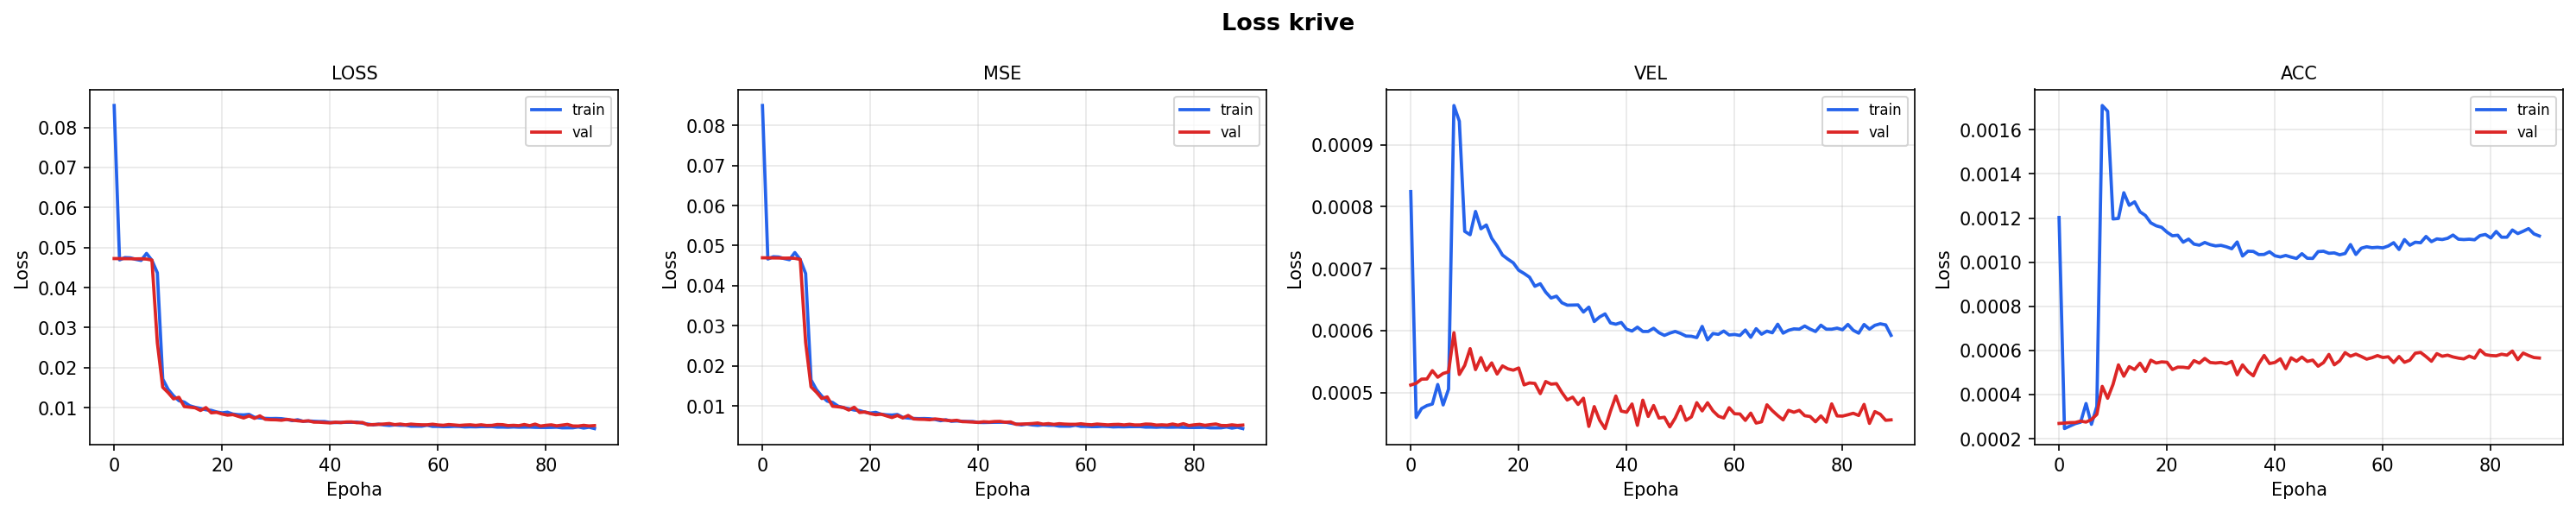

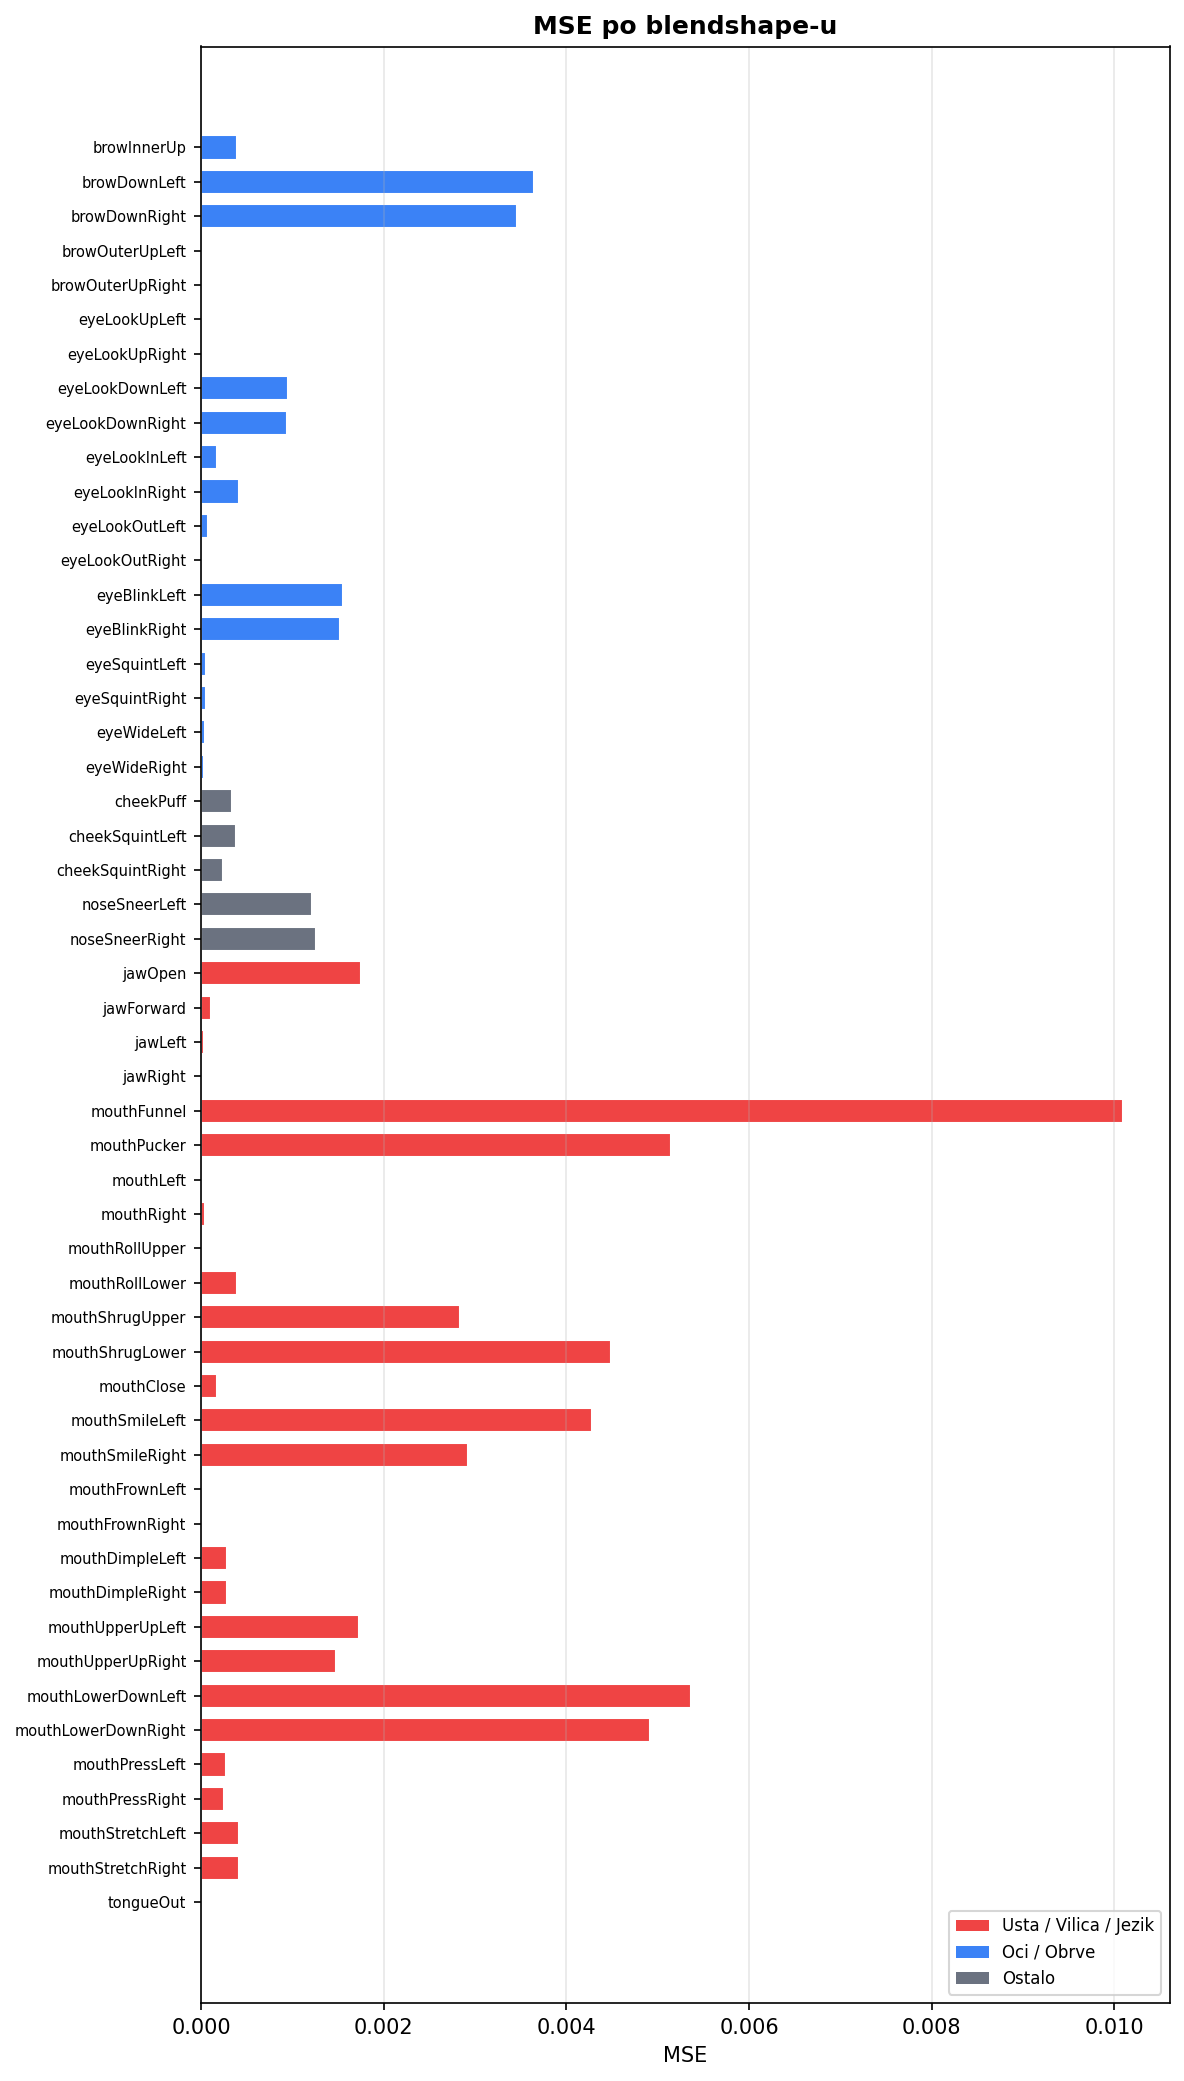

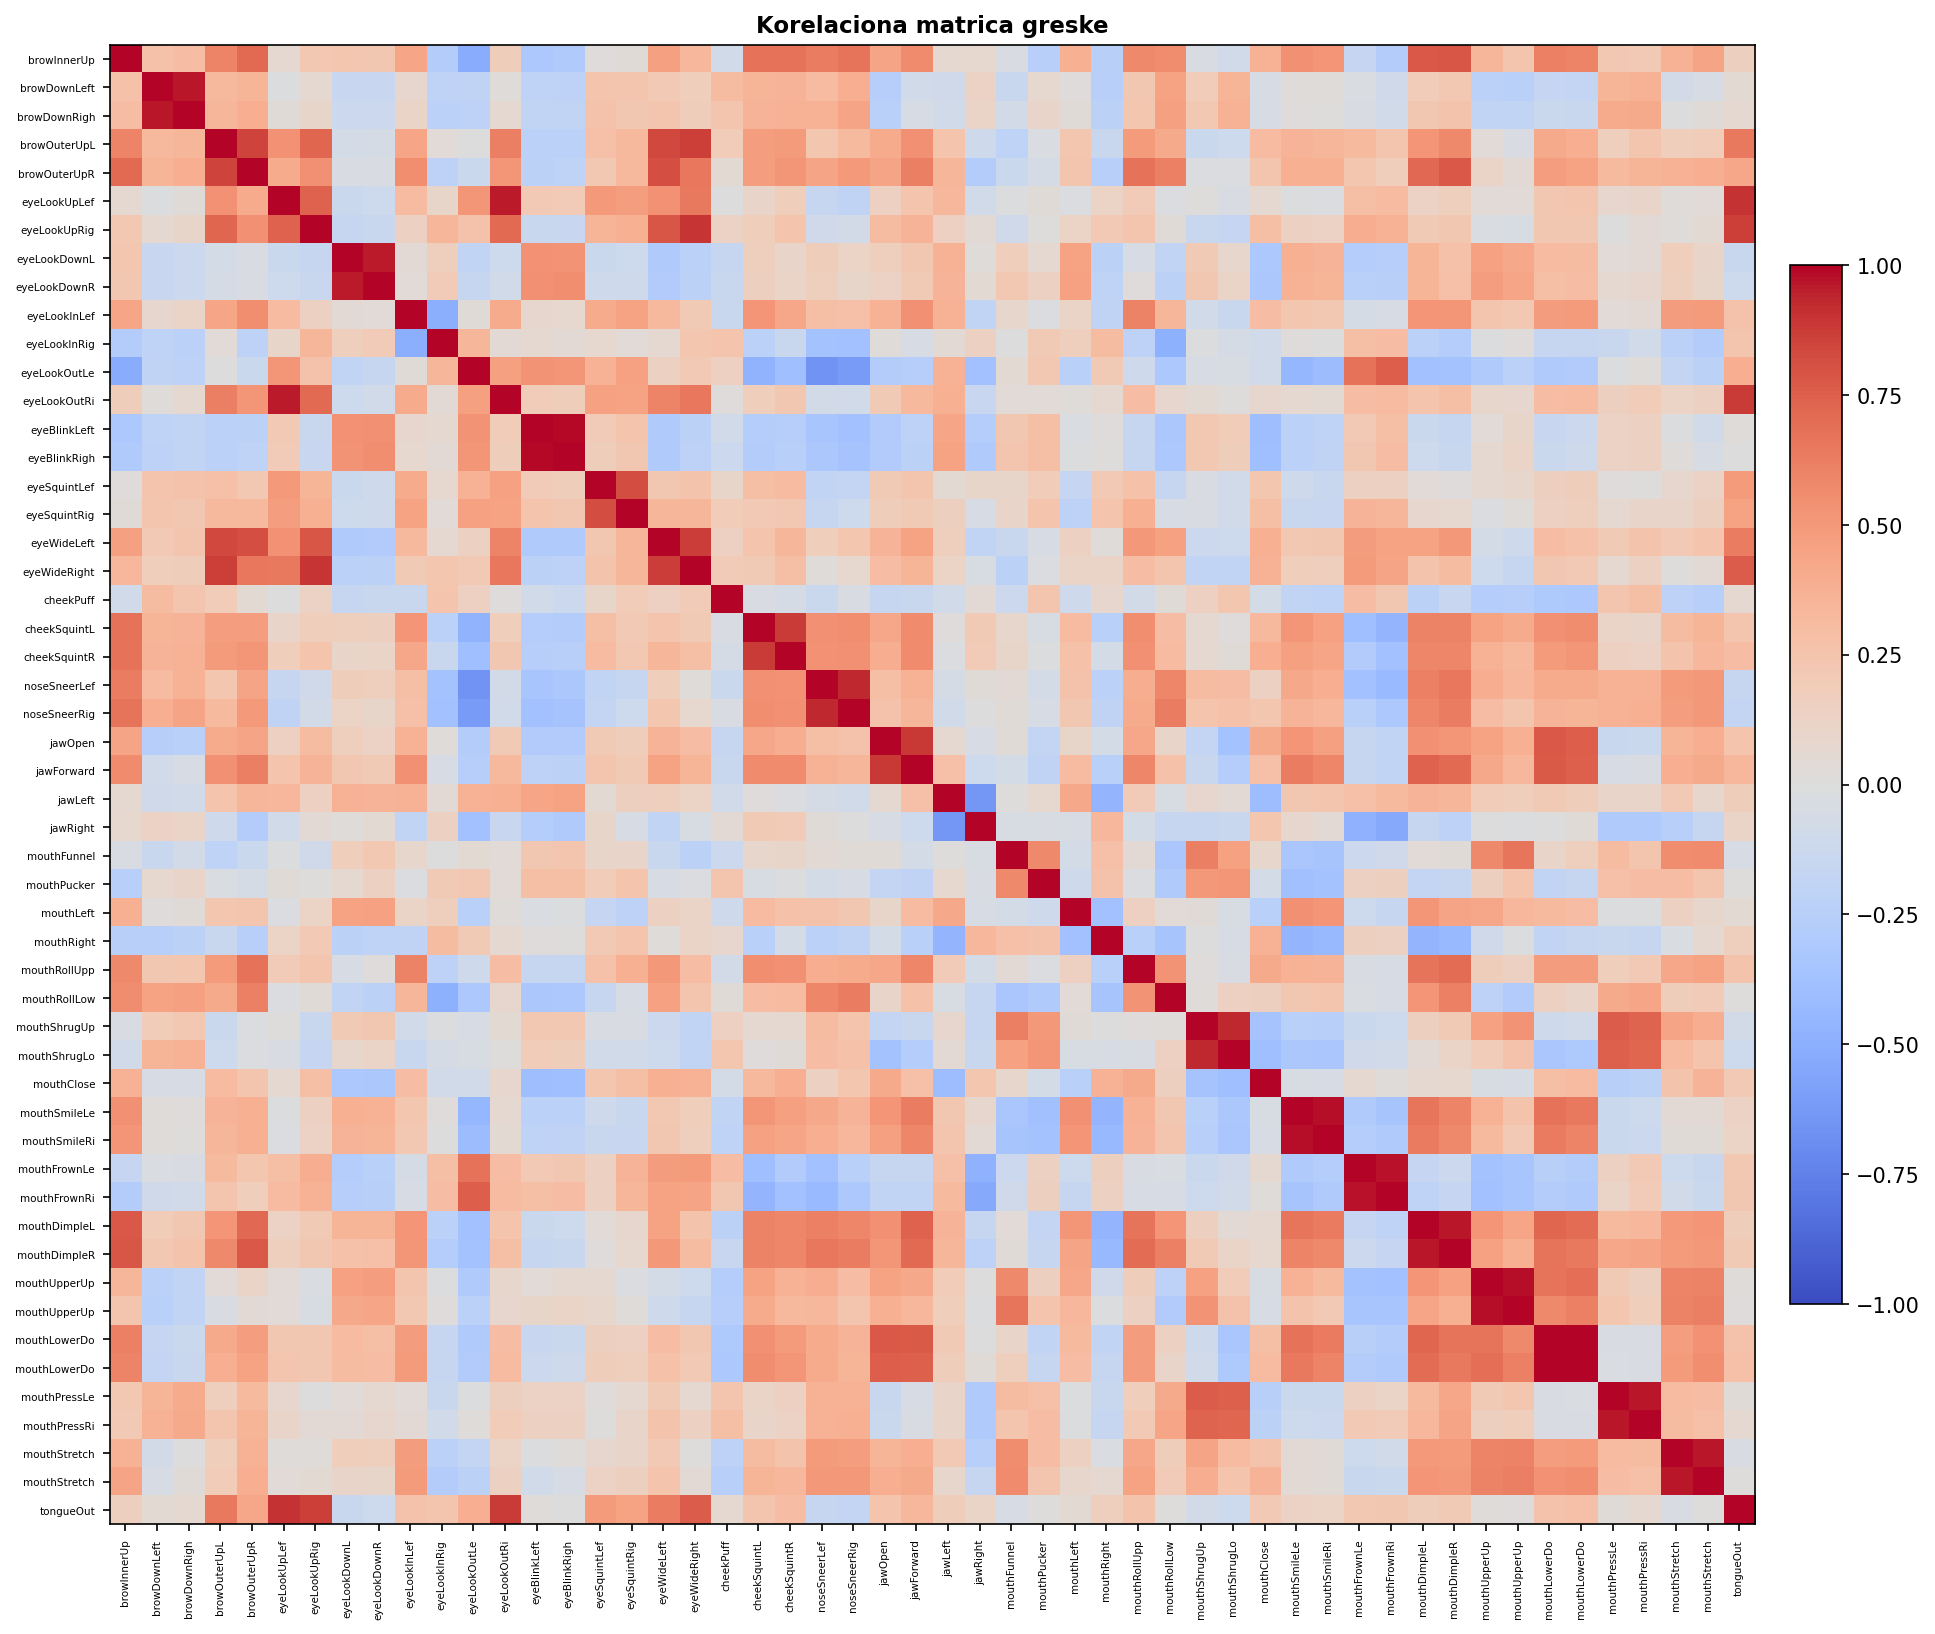

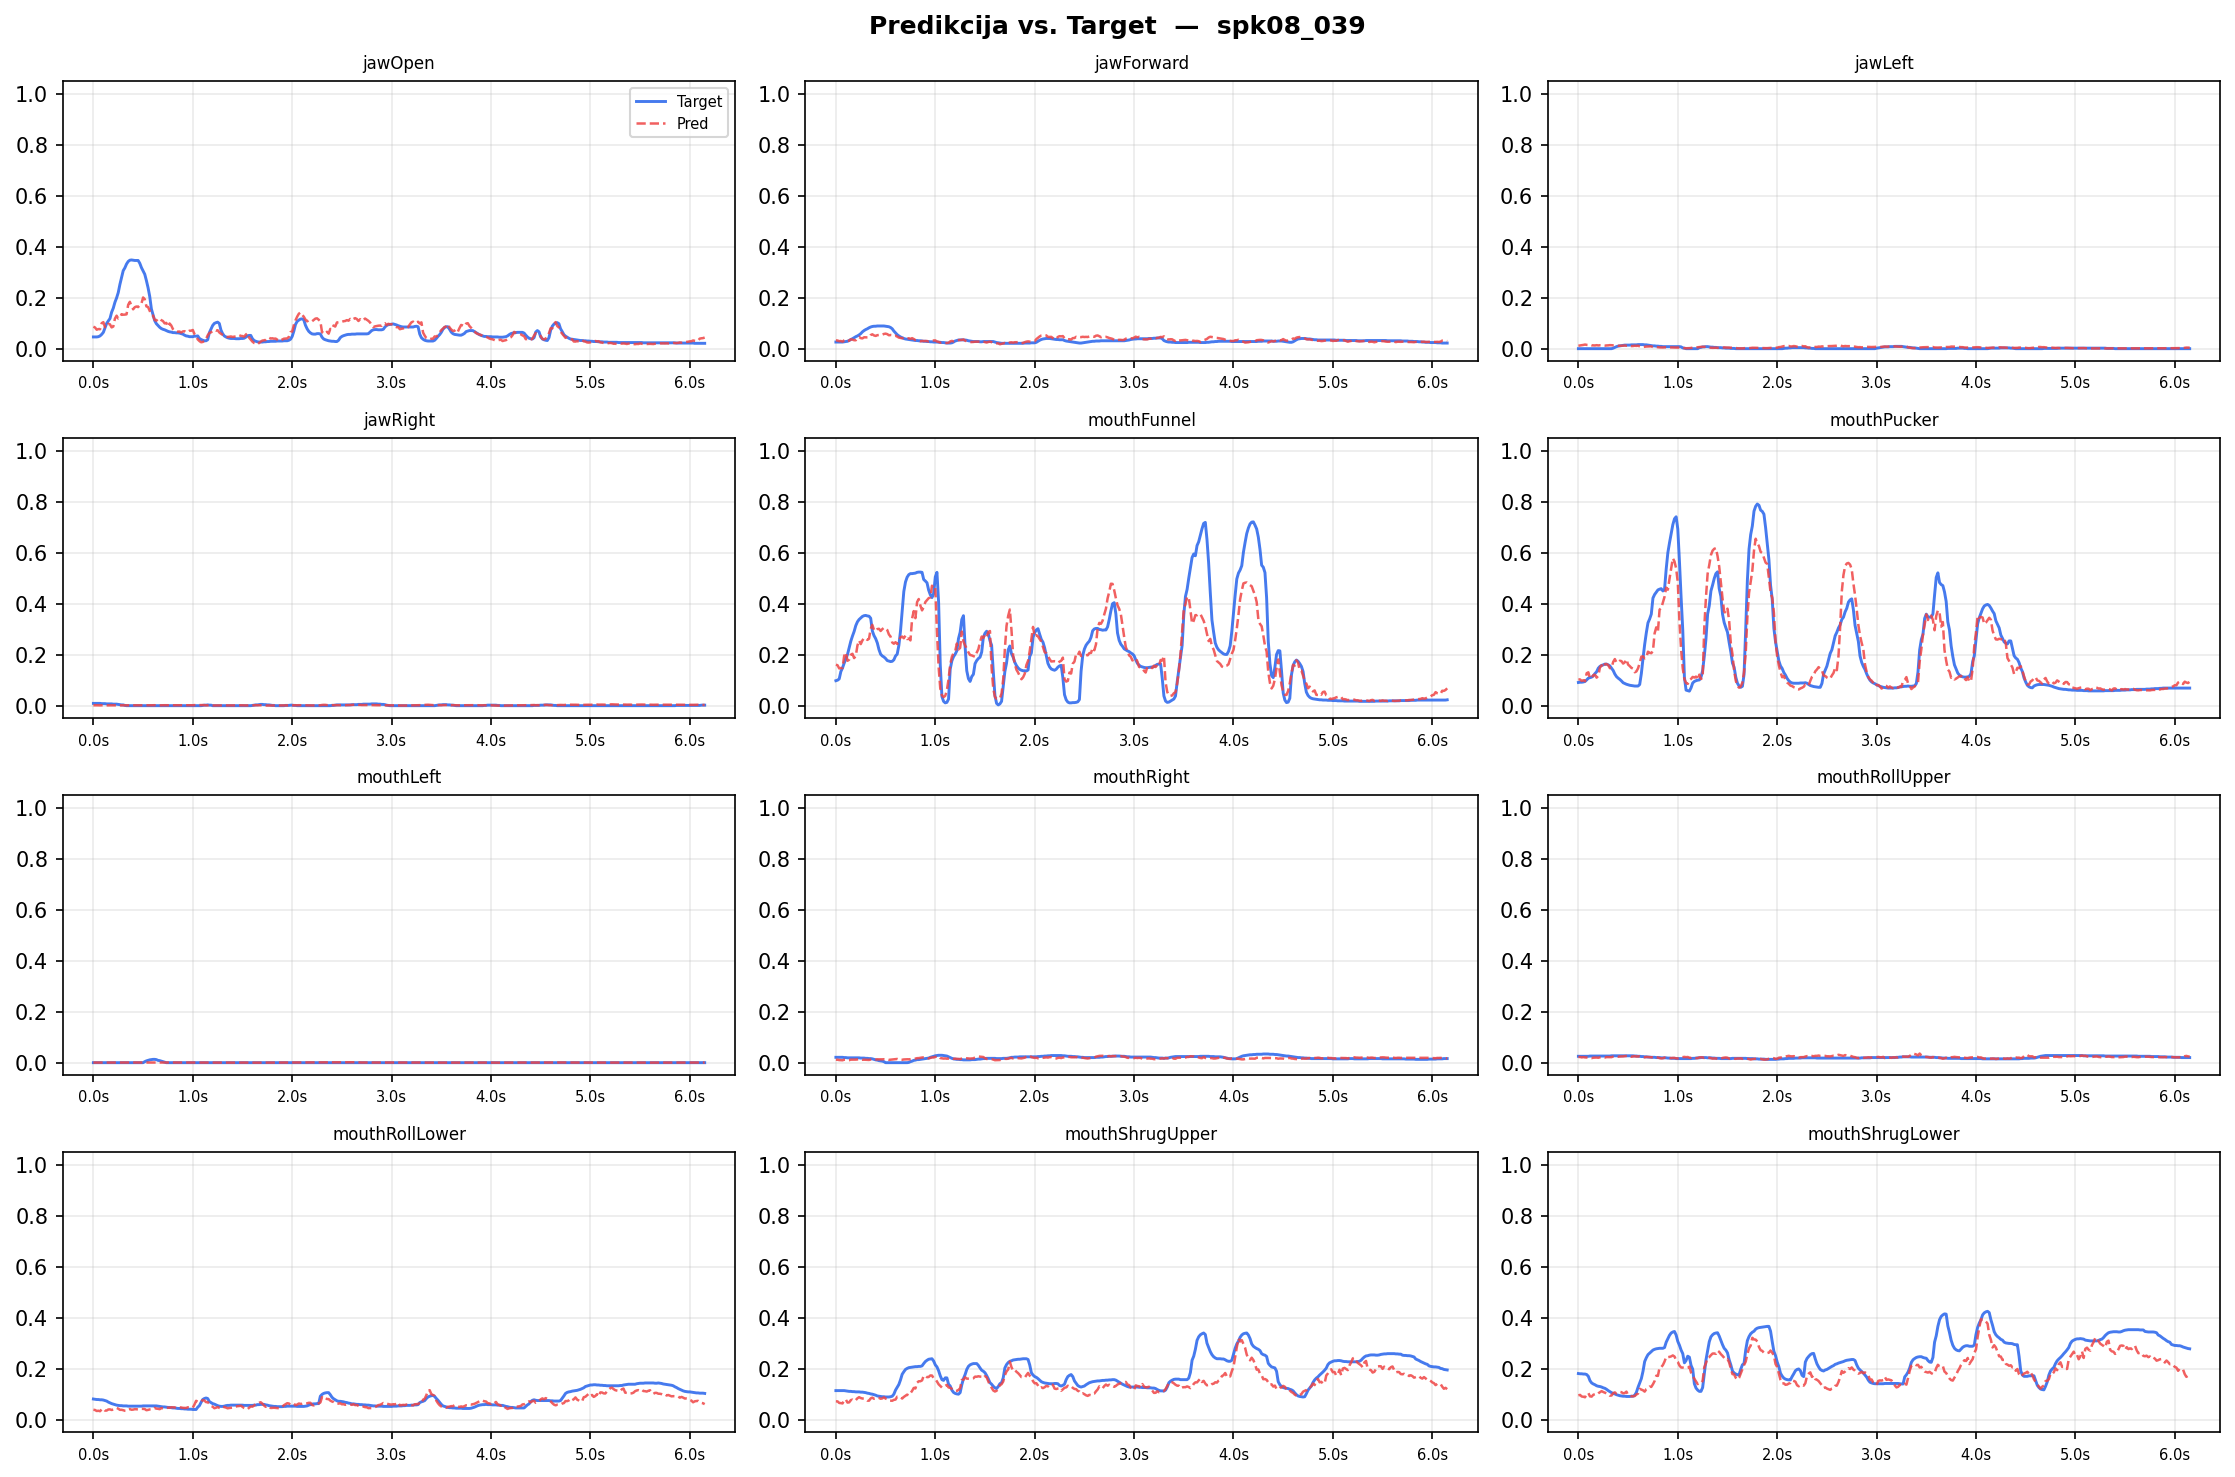

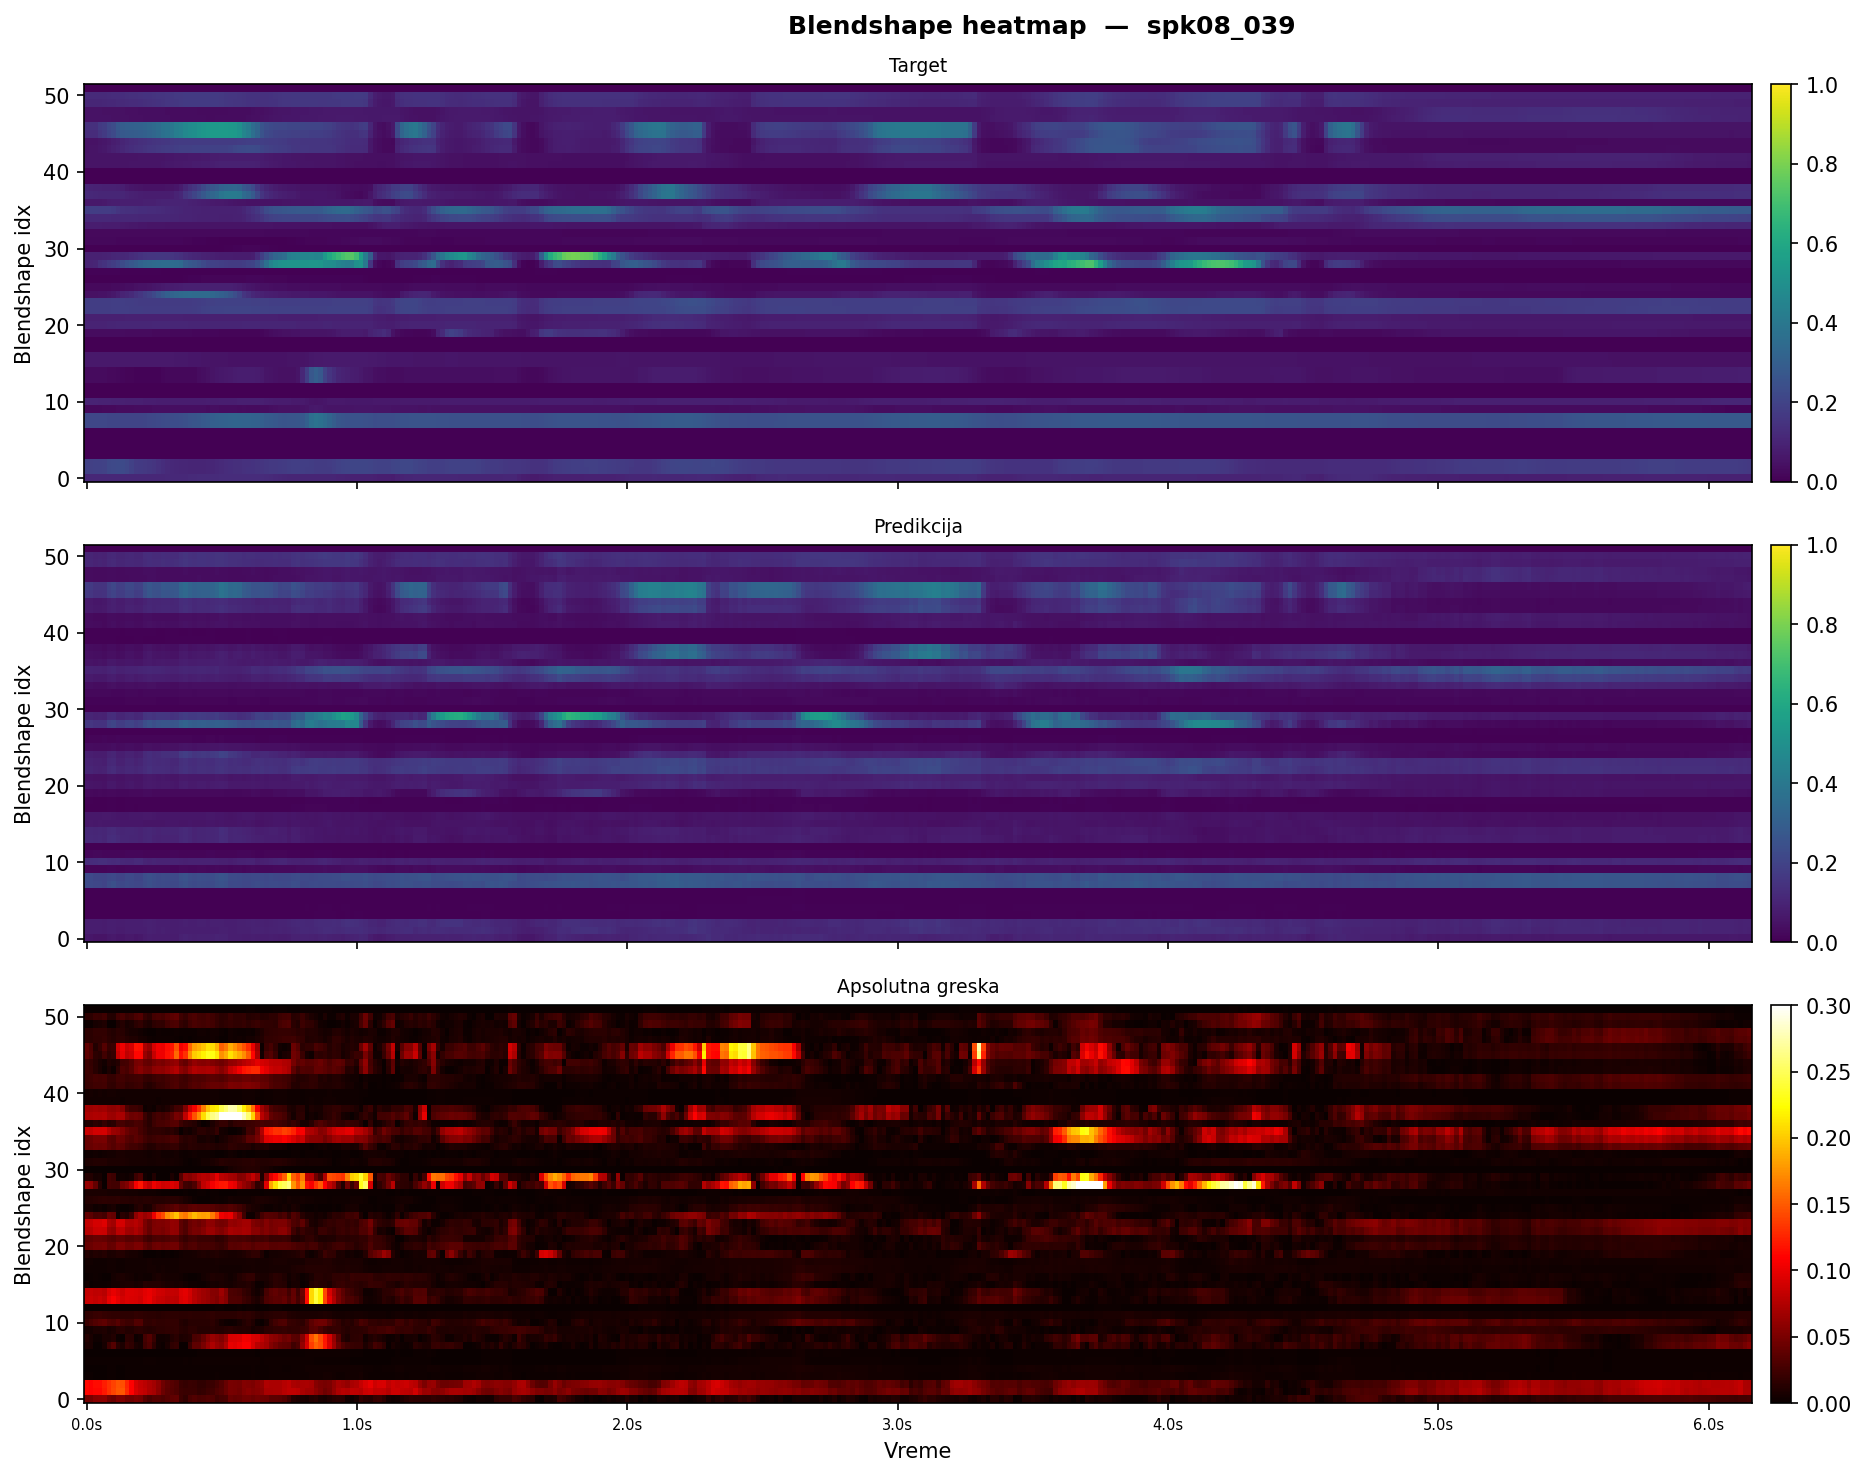

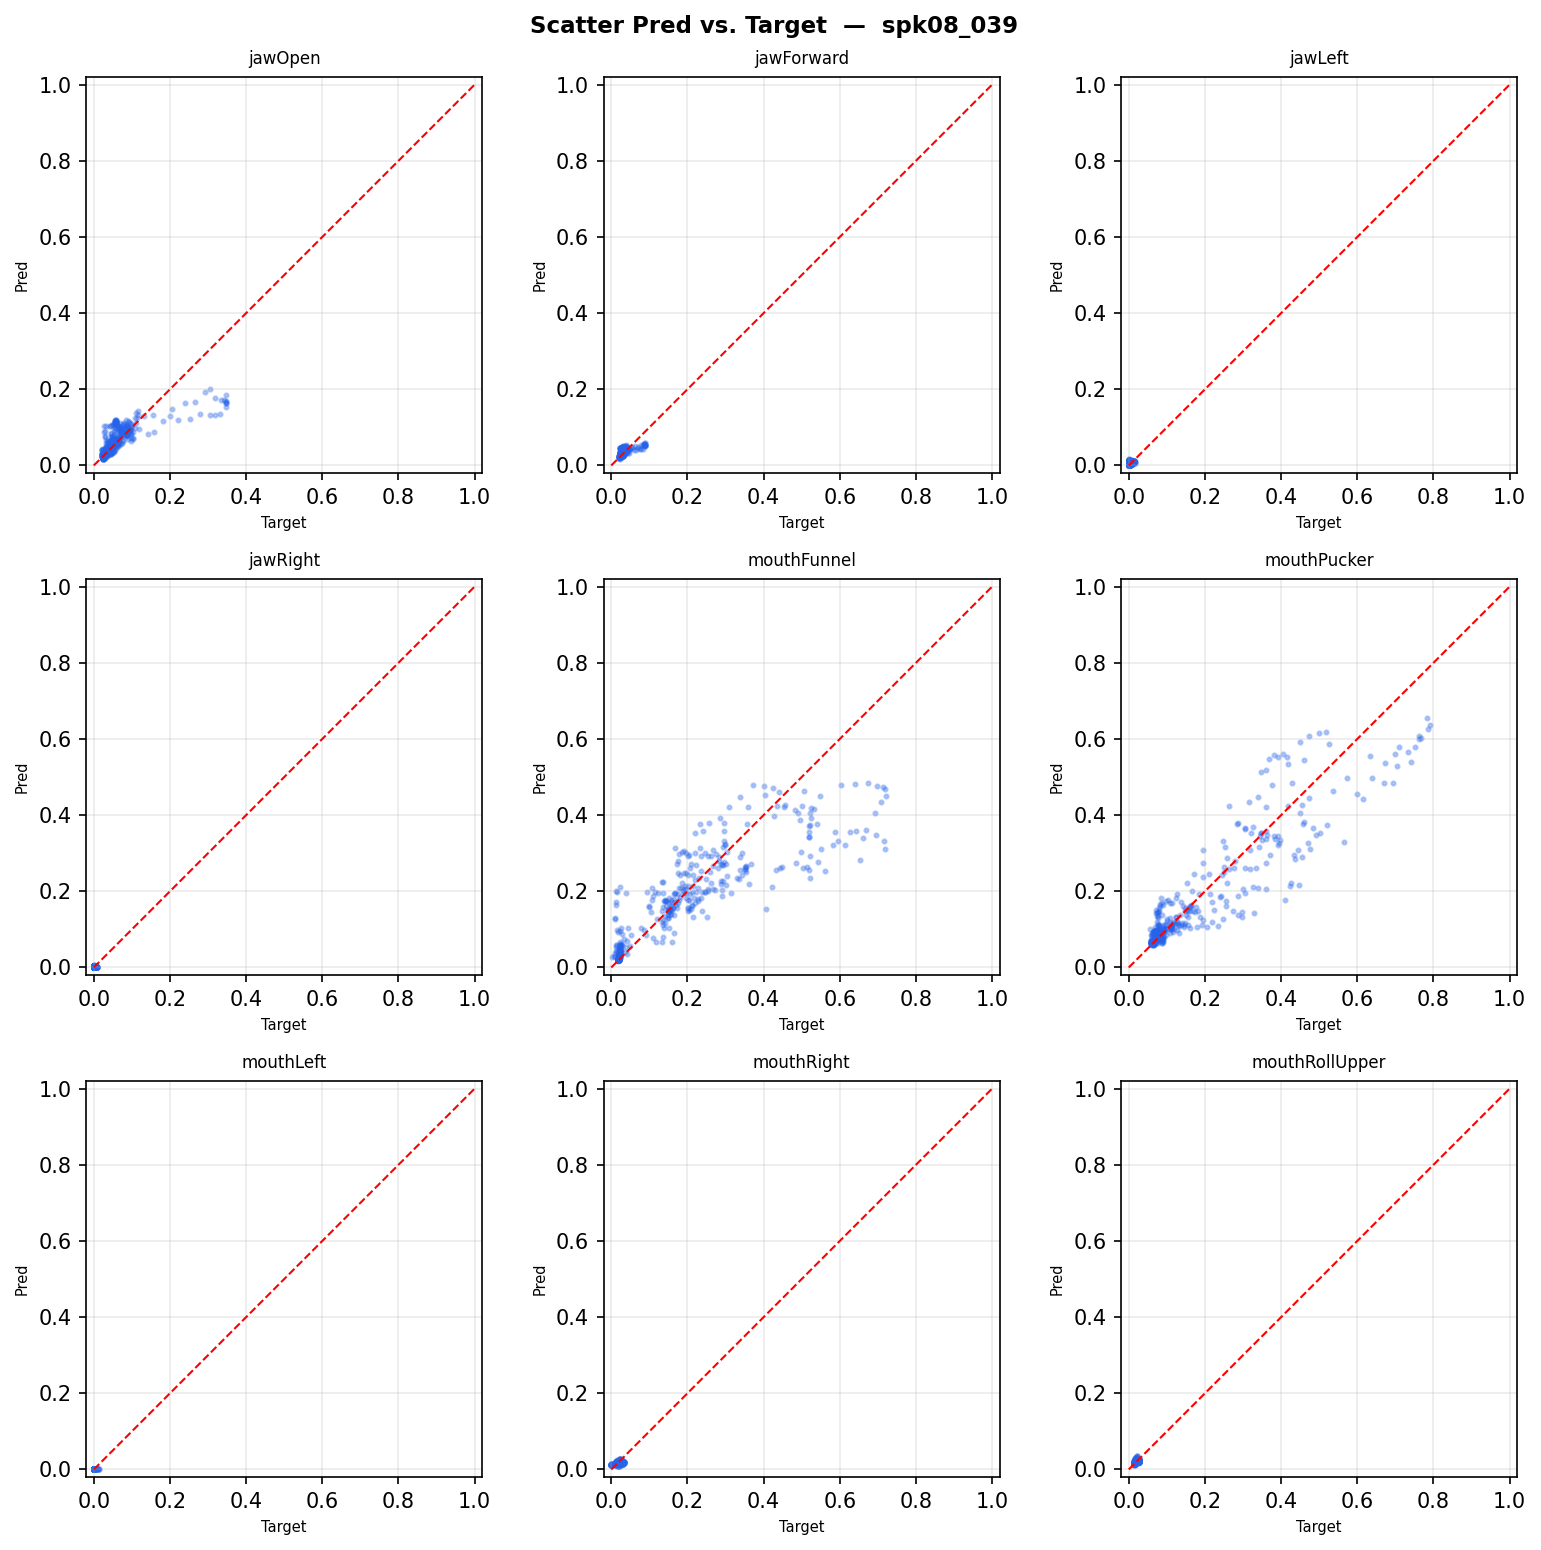

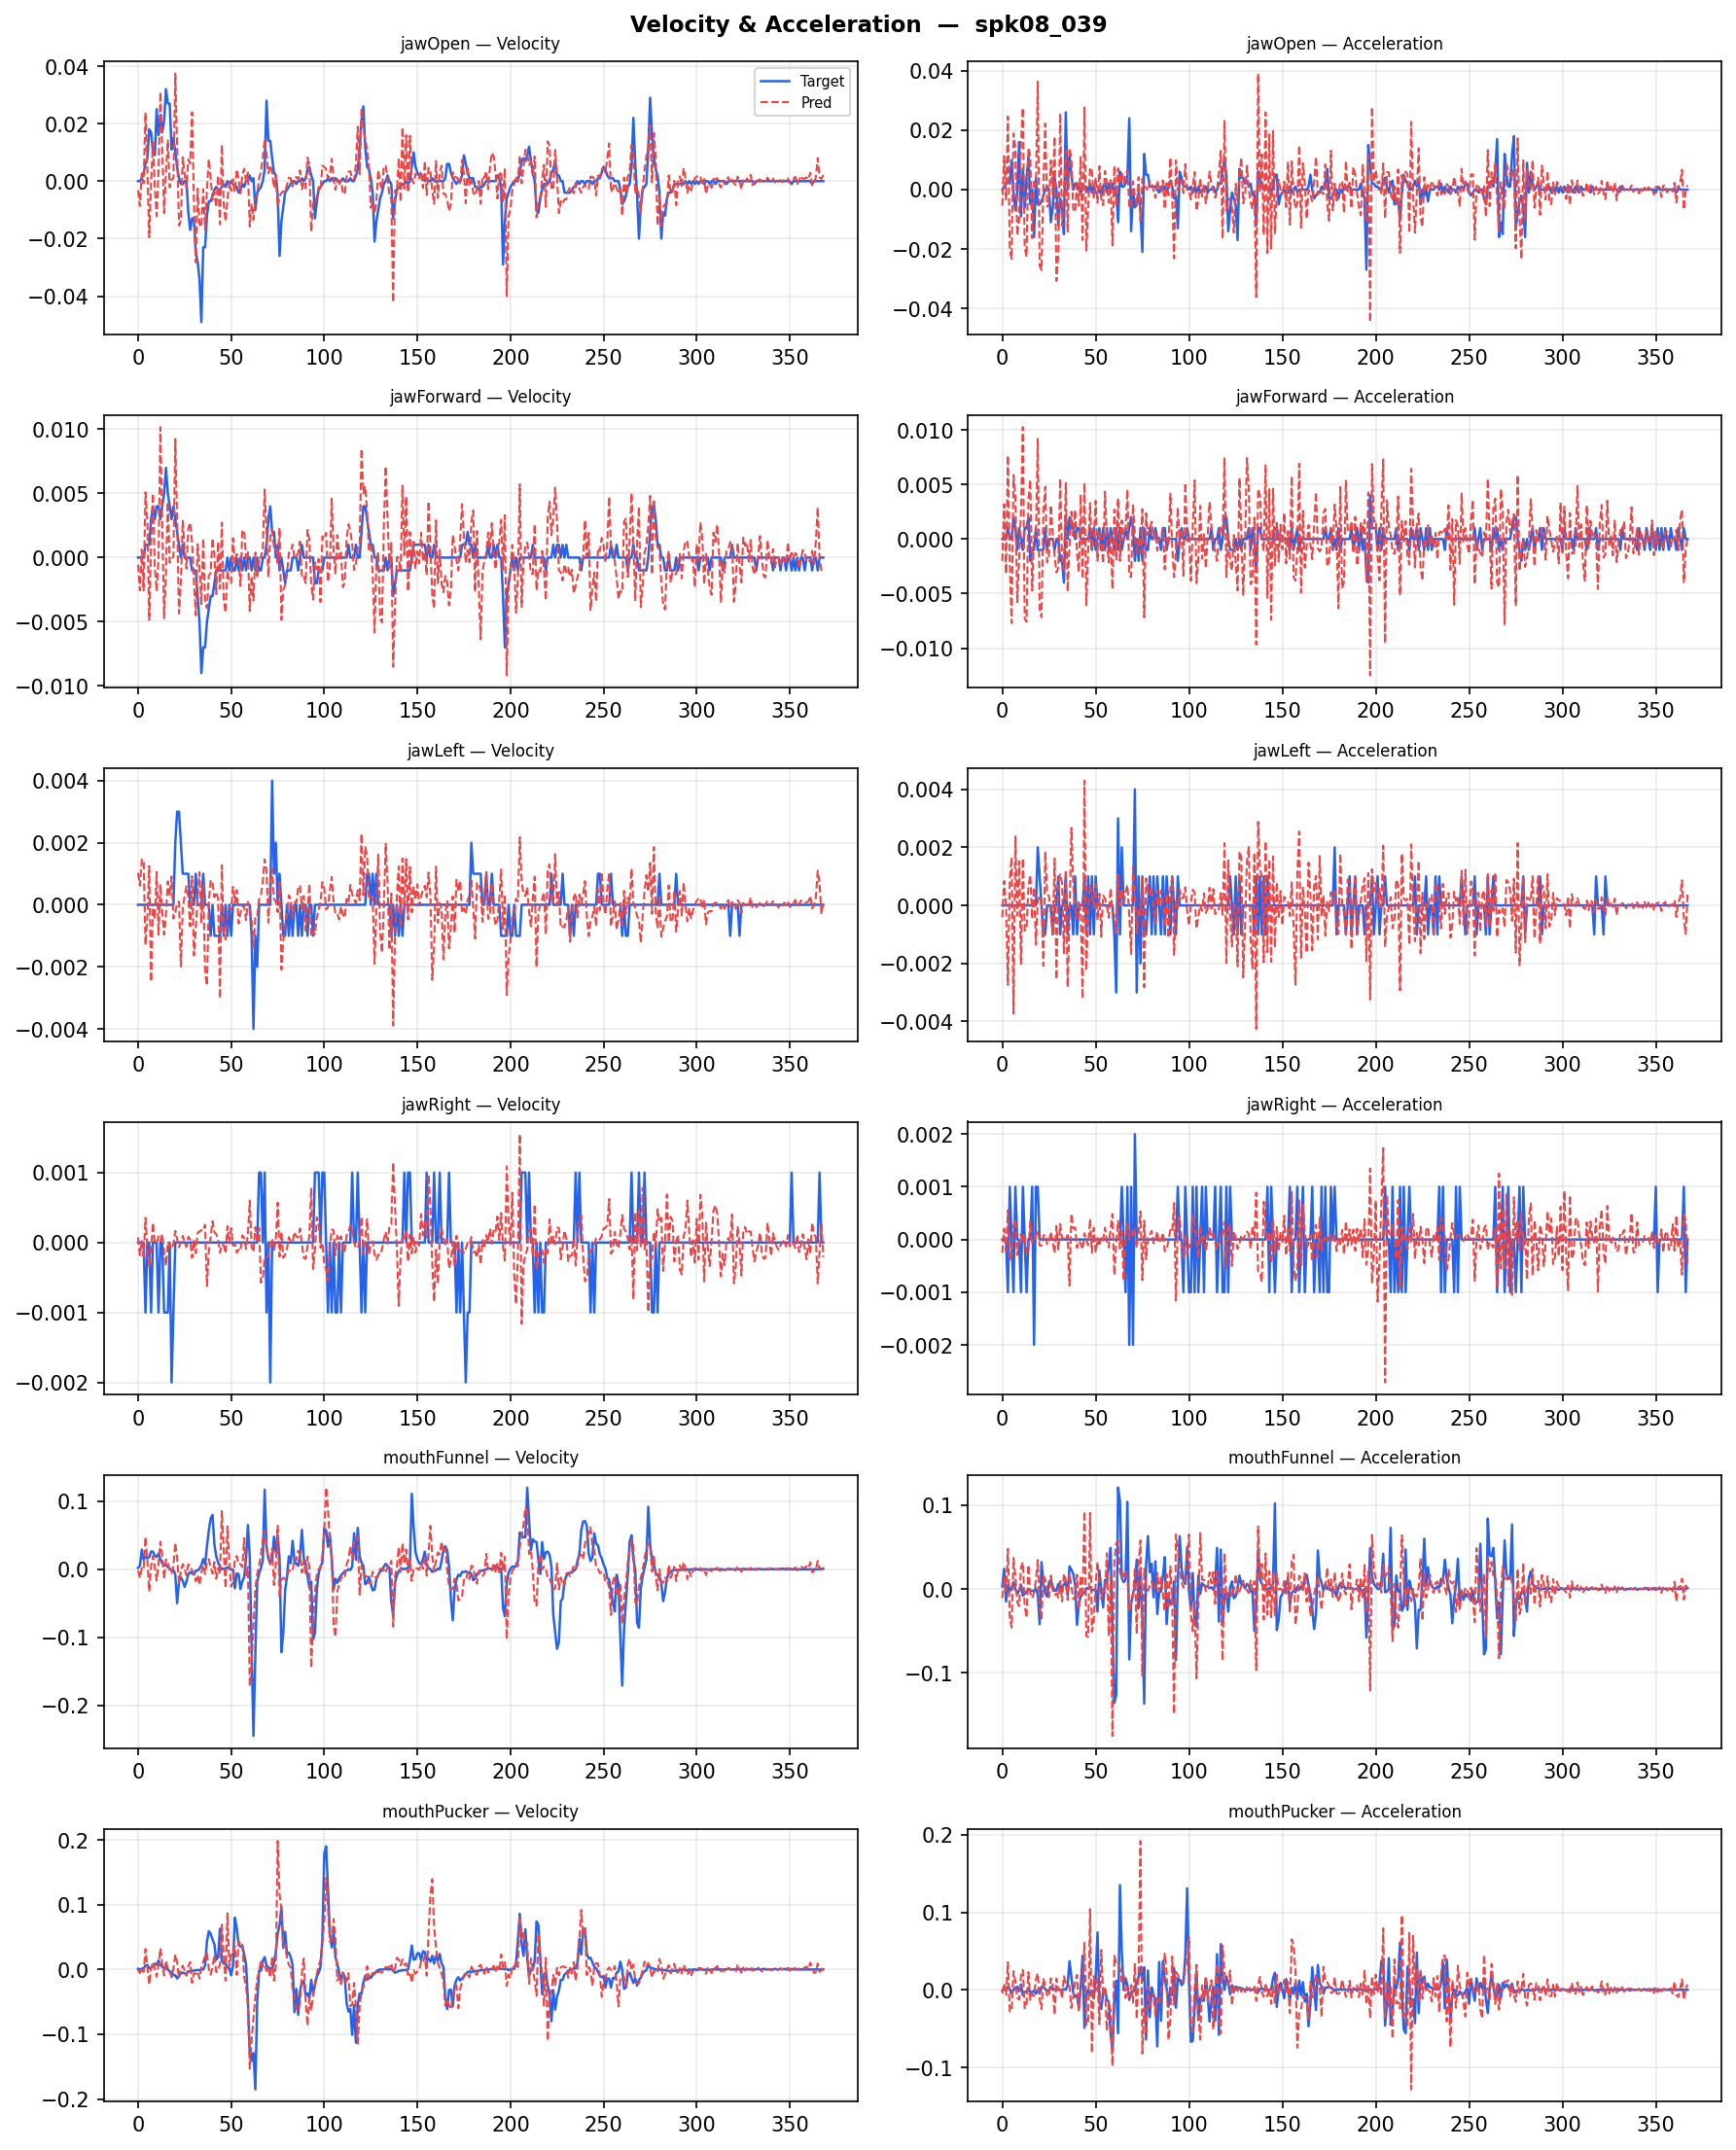

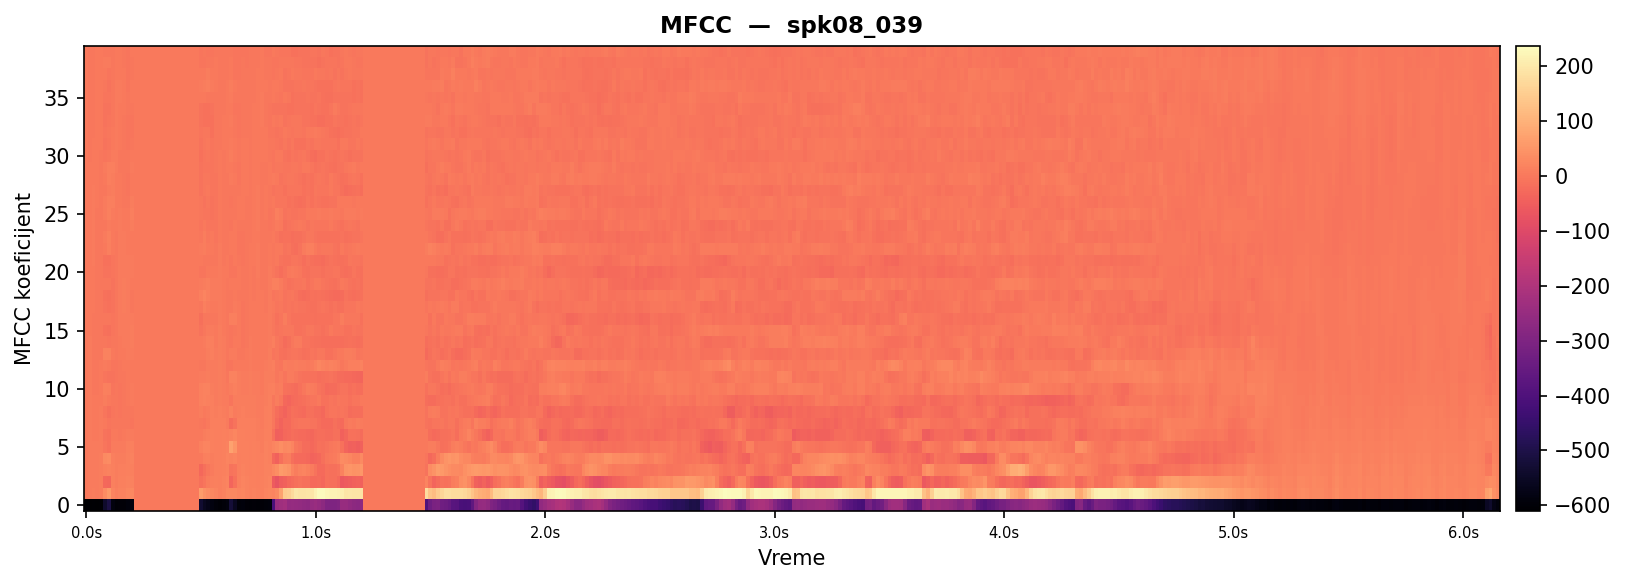

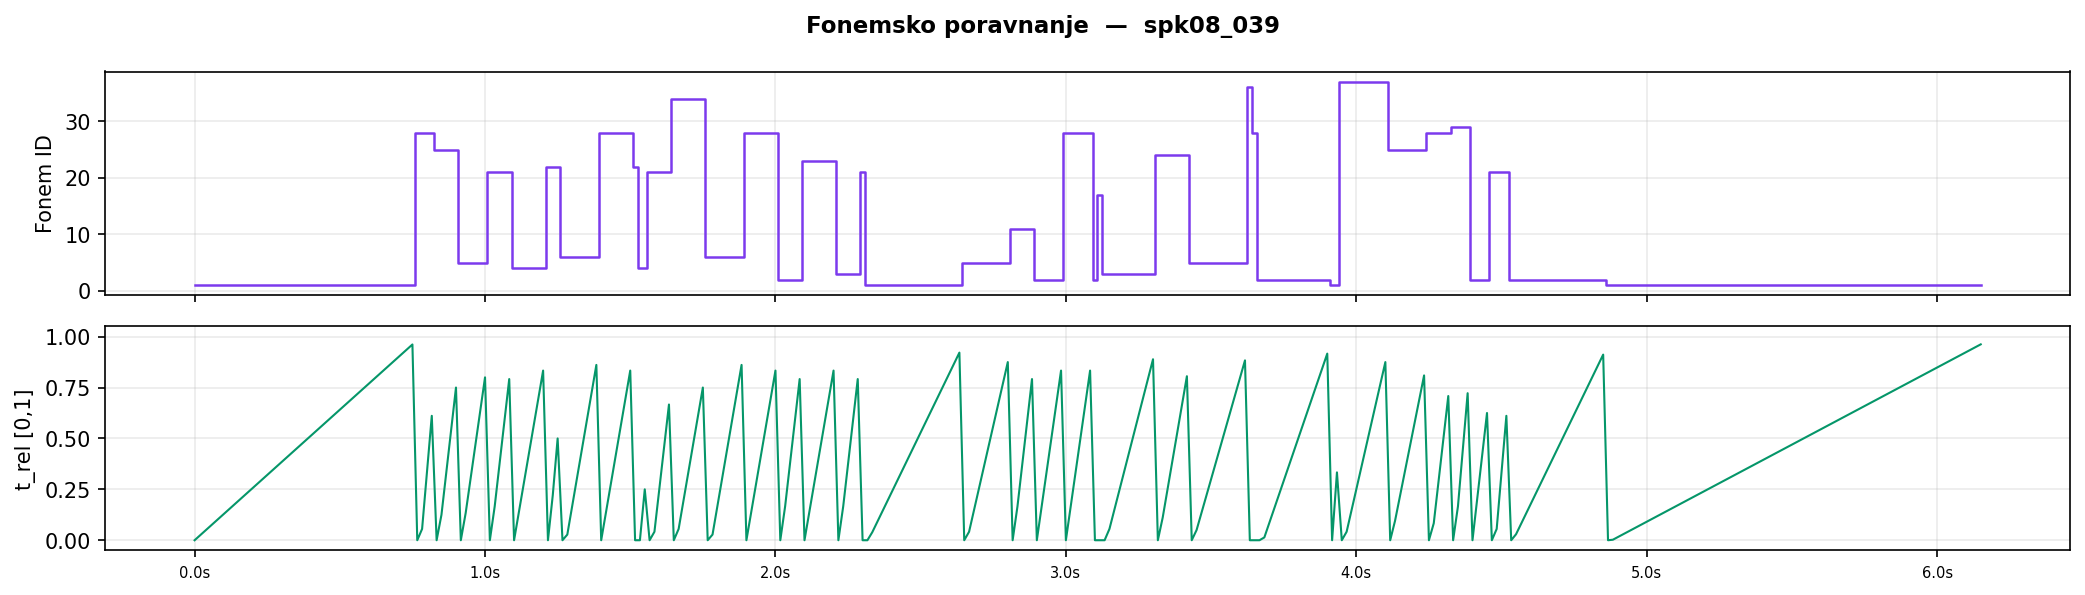

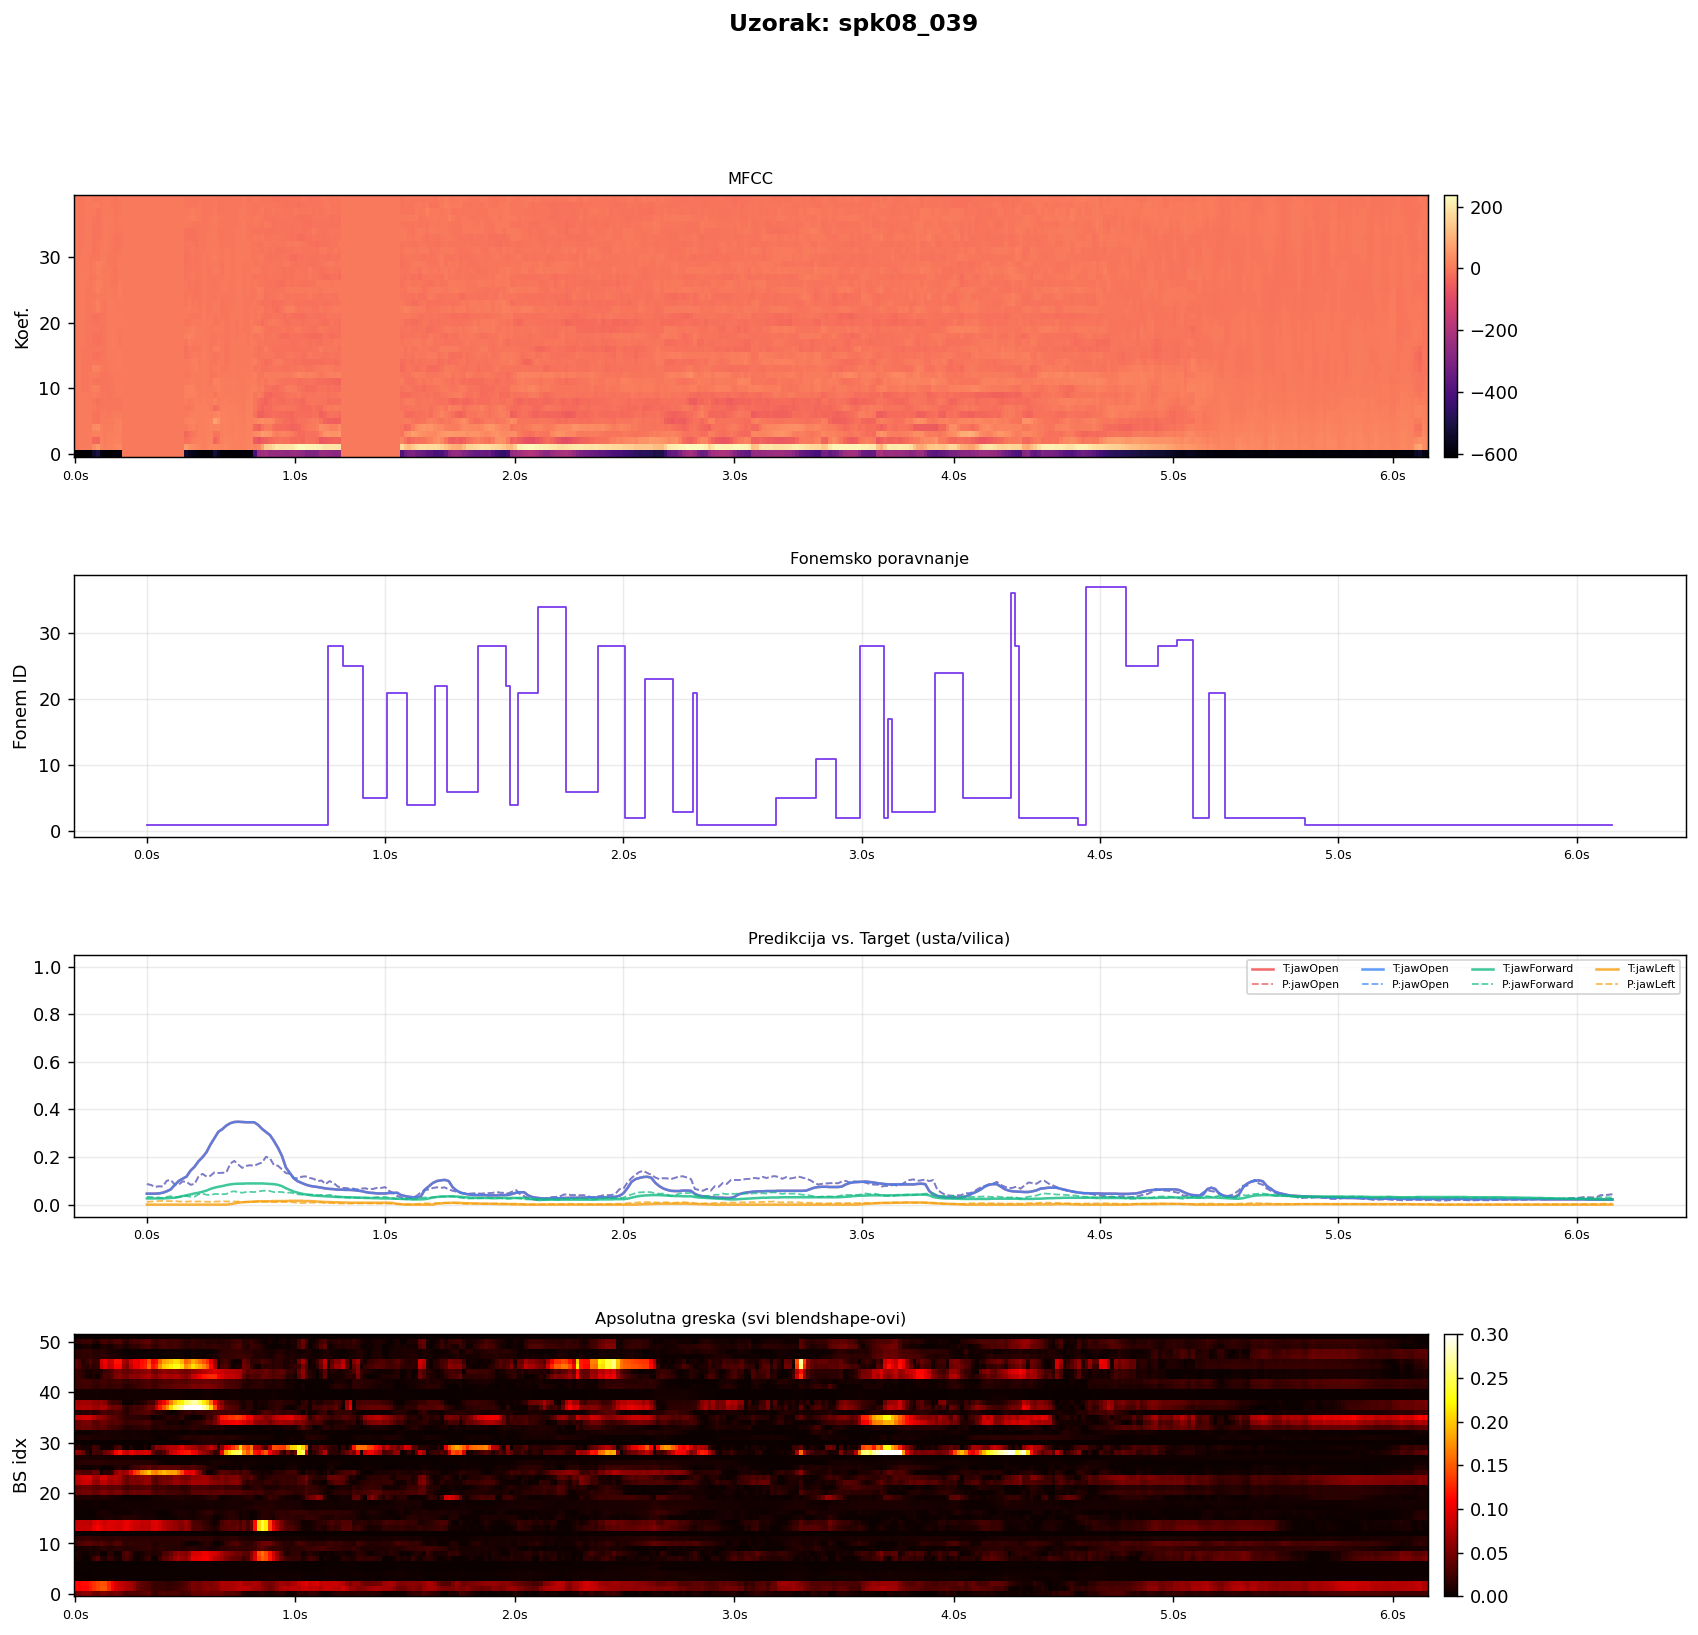


[ResultsManager] Sesija zavrsena.
[ResultsManager]   Rezultati: /content/results/tcn_mfcc_20260410_124532


[Train] Best val_loss : 0.0054
[Train] Best ckpt     : /content/results/tcn_mfcc_20260410_124532/checkpoints/best_model.pt
[Train] Rezultati     : /content/results/tcn_mfcc_20260410_124532


In [10]:
from scripts.train import train

session_path = train(
    data_root=DATA_ROOT,
    model_type="tcn",
    audio_type="mfcc",

    # Model architecture
    d_model=256,
    n_channels=256,
    n_layers=5,
    dropout=0.1,
    n_speakers=2,
    use_phonemes=True,

    # Training
    lr=5e-4,
    batch_size=8,
    weight_decay=5e-5,
    patience=10,
    epochs=100,

    device='cuda',
    results_root=result_dict,
)


In [11]:
import os, torch

print("Saved sessions:")
if os.path.exists(result_dict):
    for session in sorted(os.listdir(result_dict)):
        session_path = os.path.join(result_dict, session)
        best_model   = os.path.join(session_path, "checkpoints", "best_model.pt")
        mark = "✓" if os.path.isfile(best_model) else "✗"
        print(f"  [{mark}] {session}")
        if os.path.isfile(best_model):
            ckpt = torch.load(best_model, map_location="cpu", weights_only=False)
            print(f"        best val_loss = {ckpt.get('val_loss', float('nan')):.4f}  "
                  f"epoch = {ckpt.get('epoch', '?')}")
else:
    print(f"Results root not found: {result_dict}")

Saved sessions:
  [✓] tcn_mfcc_20260410_124532
        best val_loss = 0.0054  epoch = 80
